# Model Inference

## Objective

In this notebook we test the trained SRCNN model on a sample image from the dataset and compare the reconstructed image with the ground truth.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [2]:
import matplotlib.pyplot as plt
import torch

from src.models.srcnn import SRCNN
from src.dataloader import get_train_loader
from src.checkpoint import load_model
from src.utils.image_utils import tensor_to_image

## Device

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


## Load Data

In [4]:
train_loader = get_train_loader()

## Load Trained Model

In [ ]:
model = SRCNN()

model = load_model(
    model,
    "../results/checkpoints/srcnn_x2_200epochs.pth",
    device
)

model.eval()

c:\Users\aless\Documents\RetroSR-CNN\src\checkpoint.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(filepath, map_location=device)


SRCNN(
  (feature_extraction): Sequential(
    (0): Conv2d(3, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
    (1): ReLU(inplace=True)
  )
  (mapping): Sequential(
    (0): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU(inplace=True)
  )
  (reconstruction): Conv2d(32, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
)

## Load One Sample

In [6]:
lr_batch, hr_batch = next(iter(train_loader))

print(lr_batch.shape)
print(hr_batch.shape)

torch.Size([16, 3, 96, 96])
torch.Size([16, 3, 96, 96])


## Run Inference

In [7]:
lr_image = lr_batch[0].unsqueeze(0).to(device)

with torch.no_grad():
    prediction = model(lr_image)

print(prediction.shape)

torch.Size([1, 3, 96, 96])


## Convert Tensors to Images

In [8]:
prediction = prediction.squeeze(0)
lr_image = lr_image.squeeze(0)
hr_image = hr_batch[0]

prediction = tensor_to_image(prediction)
lr_image = tensor_to_image(lr_image)
hr_image = tensor_to_image(hr_image)

<module 'torchvision.transforms' from 'c:\\Users\\aless\\AppData\\Local\\Programs\\Python\\Python310\\lib\\site-packages\\torchvision\\transforms\\__init__.py'>
<module 'torchvision.transforms' from 'c:\\Users\\aless\\AppData\\Local\\Programs\\Python\\Python310\\lib\\site-packages\\torchvision\\transforms\\__init__.py'>
<module 'torchvision.transforms' from 'c:\\Users\\aless\\AppData\\Local\\Programs\\Python\\Python310\\lib\\site-packages\\torchvision\\transforms\\__init__.py'>


## Visual Comparison

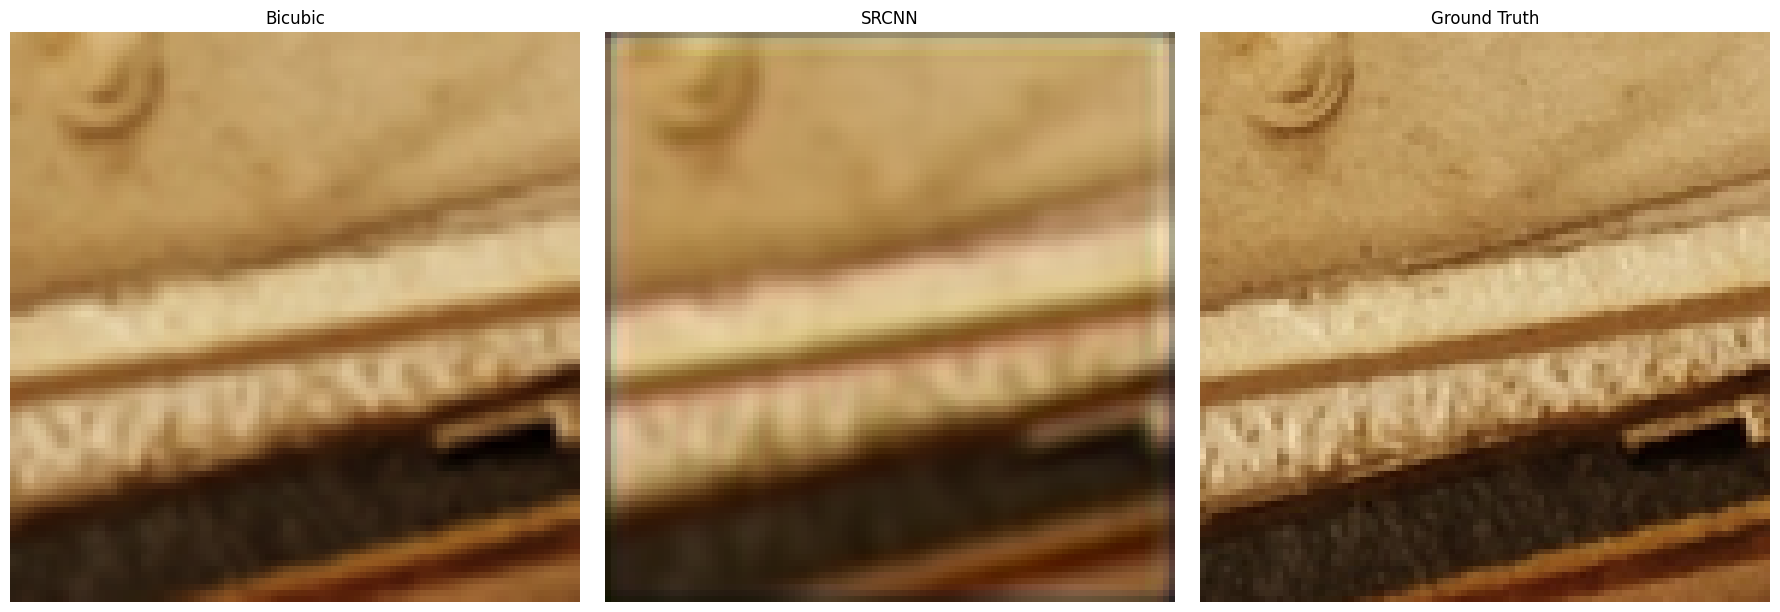

In [9]:
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(lr_image)
plt.title("Bicubic")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(prediction)
plt.title("SRCNN")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(hr_image)
plt.title("Ground Truth")
plt.axis("off")

plt.tight_layout()

plt.show()